In [1]:
# %% [markdown]
# shape suffixes 

# Throughout this tutorial, we use **shape suffixes** to make tensor dimensions obvious at a glance:

# | Suffix | Meaning |
# |--------|---------|
# | `B` | Batch size |
# | `L` | Sequence length (including special tokens) |
# | `A` | Amino acid positions (excluding special tokens) |
# | `H` | Attention heads |
# | `D` | Hidden dimension |
# | `V` | Vocabulary size |
# | `F` | SAE feature dimension |
# | `K` | Top-k |
# | `S` | String length |

# For example, `attn_weights_BHLL` is a tensor with shape `(batch, heads, seq_len, seq_len)`.


# %%
from __future__ import annotations
import gc
import json
import os
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass
from transformers import EsmForMaskedLM, EsmTokenizer
from nnsight import NNsight

# =============================================================================
# Configuration
# =============================================================================
DATA_PATH = 'data/full_seq_dict.json'
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"  # 650M params, 33 layers
# MODEL_NAME = "facebook/esm2_t6_8M_UR50D"  # 8M params, 6 layers

PROTEINS = {
    "2B61A": {"contact_pair": (182, 316), "clean_flank": 44, "corrupt_flank": 43},
    "1PVGA": {"contact_pair": (101, 202), "clean_flank": 65, "corrupt_flank": 63},
}
SEGMENT_RADIUS = 5  # residues on each side of contact position

# =============================================================================
# Utilities
# =============================================================================
def log_memory(label=""):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resv = torch.cuda.memory_reserved() / 1e9
        print(f"[Memory - {label}] Allocated: {alloc:.2f} GB, Reserved: {resv:.2f} GB")

def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

def get_cache_path(protein: str, clean_flank: int, corrupt_flank: int) -> str:
    """Get path for cached metrics."""
    import os
    cache_dir = "reports/cache"
    os.makedirs(cache_dir, exist_ok=True)
    return f"{cache_dir}/{protein}_c{clean_flank}_x{corrupt_flank}_metrics.pt"

def save_metrics_cache(
    protein: str,
    clean_flank: int,
    corrupt_flank: int,
    metrics: dict[str, torch.Tensor],
) -> None:
    """
    Save all head metrics to cache file.

    Args:
        protein: Protein ID
        clean_flank: Clean flank size
        corrupt_flank: Corrupt flank size
        metrics: Dict of metric_name -> (num_layers, num_heads) tensor
    """
    cache_path = get_cache_path(protein, clean_flank, corrupt_flank)
    cache_data = {
        "protein": protein,
        "clean_flank": clean_flank,
        "corrupt_flank": corrupt_flank,
        "metrics": metrics,
    }
    torch.save(cache_data, cache_path)
    print(f"✓ Saved metrics cache to {cache_path}")
    print(f"  Cached metrics: {', '.join(metrics.keys())}")

def load_metrics_cache(protein: str, clean_flank: int, corrupt_flank: int) -> dict[str, torch.Tensor] | None:
    """
    Load cached metrics if they exist.

    Returns:
        Dict of metric_name -> (num_layers, num_heads) tensor, or None if cache doesn't exist
    """
    import os
    cache_path = get_cache_path(protein, clean_flank, corrupt_flank)

    if not os.path.exists(cache_path):
        return None

    try:
        cache_data = torch.load(cache_path)
        print(f"✓ Loaded metrics cache from {cache_path}")
        print(f"  Cached metrics: {', '.join(cache_data['metrics'].keys())}")
        return cache_data["metrics"]
    except Exception as e:
        print(f"⚠ Failed to load cache: {e}")
        return None

def compute_diff_metrics_torch(clean_attn_LL: torch.Tensor, corrupt_attn_LL: torch.Tensor) -> dict[str, float]:
    """
    Compute multiple metrics quantifying attention pattern differences.

    For attention matrices (probability distributions), L1 norm is most interpretable.

    Args:
        clean_attn_LL: Clean attention matrix (seq_len, seq_len)
        corrupt_attn_LL: Corrupt attention matrix (seq_len, seq_len)

    Returns:
        Dict of metric_name -> value:
        - diff_l1: Sum of absolute differences (total variation distance)
        - diff_max: Maximum absolute difference (worst-case deviation)
        - diff_l2: Frobenius norm (L2) for comparison
    """
    diff = clean_attn_LL - corrupt_attn_LL

    return {
        "diff_l1": torch.sum(torch.abs(diff)).item(),
        "diff_max": torch.max(torch.abs(diff)).item(),
        "diff_l2": torch.sqrt(torch.sum(diff ** 2)).item(),
    }

# =============================================================================
# Core Functions
# =============================================================================
@dataclass
class ContactSegment:
    ss1_start: int
    ss1_end: int
    ss2_start: int
    ss2_end: int

    @classmethod
    def from_contact_pair(cls, pos1: int, pos2: int, radius: int = SEGMENT_RADIUS):
        return cls(pos1 - radius, pos1 + radius + 1, pos2 - radius, pos2 + radius + 1)

def mask_with_flanks(seq_S: str, segment: ContactSegment, flank_size: int) -> str:
    """Mask sequence except for contact segments and flanking regions."""
    seq_len = len(seq_S)
    masked_L: list[str] = ["<mask>"] * seq_len

    # Unmask contact segments
    masked_L[segment.ss1_start:segment.ss1_end] = list(seq_S[segment.ss1_start:segment.ss1_end])
    masked_L[segment.ss2_start:segment.ss2_end] = list(seq_S[segment.ss2_start:segment.ss2_end])

    # Unmask flanks
    left_flank_idxs = range(max(0, segment.ss1_start - flank_size), segment.ss1_start)
    right_flank_idxs = range(segment.ss2_end, min(seq_len, segment.ss2_end + flank_size))
    for i in left_flank_idxs:
        masked_L[i] = seq_S[i]
    for i in right_flank_idxs:
        masked_L[i] = seq_S[i]

    return "".join(masked_L)

def compute_contact_map(model, tokenizer, sequence_S: str, device: str) -> torch.Tensor:
    """Compute contact predictions for a sequence."""
    inputs_BL = tokenizer(sequence_S, return_tensors="pt").to(device)
    with torch.no_grad():
        contacts_AA = model.predict_contacts(inputs_BL['input_ids'], inputs_BL['attention_mask'])[0].cpu()
    return contacts_AA

def patching_metric(pred_contacts_AA: torch.Tensor, orig_contacts_AA: torch.Tensor, segment: ContactSegment) -> float:
    """Compute overlap metric between predicted and original contacts in segment."""
    pred_seg = pred_contacts_AA[segment.ss1_start:segment.ss1_end, segment.ss2_start:segment.ss2_end]
    orig_seg = orig_contacts_AA[segment.ss1_start:segment.ss1_end, segment.ss2_start:segment.ss2_end]
    return (torch.sum(pred_seg * orig_seg) / torch.sum(orig_seg * orig_seg)).item()

PLOT_DIR = "reports/outputs"
os.makedirs(PLOT_DIR, exist_ok=True)

def plot_contact_map(contacts_AA: torch.Tensor, title: str, filename: str | None = None):
    plt.figure(figsize=(6, 6))
    plt.imshow(contacts_AA, cmap='viridis', aspect='equal')
    plt.colorbar(label="Contact Probability")
    plt.title(title)
    plt.xlabel("Residue Index")
    plt.ylabel("Residue Index")
    plt.tight_layout()
    if filename:
        plt.savefig(f"{PLOT_DIR}/{filename}", dpi=150, bbox_inches='tight')
        print(f"  Saved plot to {PLOT_DIR}/{filename}")
    plt.close()

# =============================================================================
# Model Setup
# =============================================================================
# %%
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

esm_model = EsmForMaskedLM.from_pretrained(MODEL_NAME, attn_implementation="eager").to(device)
tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)
model = NNsight(esm_model)

print(f"Loaded {MODEL_NAME}: {esm_model.config.num_hidden_layers} layers, {esm_model.config.hidden_size} hidden")
log_memory("after model load")

# =============================================================================
# Load Data
# =============================================================================
# %%
with open(DATA_PATH, "r") as f:
    seq_dict = json.load(f)

protein = "2B61A"
config = PROTEINS[protein]
sequence_S = seq_dict[protein]
segment = ContactSegment.from_contact_pair(*config["contact_pair"])
inputs_BL = tokenizer(sequence_S, return_tensors="pt").to(device)

print(f"Protein: {protein}, Length: {len(sequence_S)}")
print(f"Contact segment: [{segment.ss1_start}:{segment.ss1_end}] x [{segment.ss2_start}:{segment.ss2_end}]")

# =============================================================================
# Compute Contact Maps
# =============================================================================
# %%
# Original (full sequence)
orig_contacts_AA = compute_contact_map(esm_model, tokenizer, sequence_S, device)
# plot_contact_map(orig_contacts_AA, f"{protein} - Full Sequence")

# %%
# Clean (larger flank - higher metric)
clean_seq_S = mask_with_flanks(sequence_S, segment, config["clean_flank"])
clean_contacts_AA = compute_contact_map(esm_model, tokenizer, clean_seq_S, device)

# Corrupt (smaller flank - lower metric)
corrupt_seq_S = mask_with_flanks(sequence_S, segment, config["corrupt_flank"])
corrupt_contacts_AA = compute_contact_map(esm_model, tokenizer, corrupt_seq_S, device)

# =============================================================================
# Results
# =============================================================================
# %%
print(f"\nPatching Metrics (flank size -> metric):")
print(f"  Original (full):     1.000")
print(f"  Clean (flank={config['clean_flank']}):   {patching_metric(clean_contacts_AA, orig_contacts_AA, segment):.4f}")
print(f"  Corrupt (flank={config['corrupt_flank']}): {patching_metric(corrupt_contacts_AA, orig_contacts_AA, segment):.4f}")

# %%
# Sweep flank sizes to find the jump
print("\nFlank sweep:")
for flank in range(config["corrupt_flank"] - 2, config["clean_flank"] + 3):
    masked_seq_S = mask_with_flanks(sequence_S, segment, flank)
    contacts_AA = compute_contact_map(esm_model, tokenizer, masked_seq_S, device)
    metric = patching_metric(contacts_AA, orig_contacts_AA, segment)
    print(f"  flank={flank:3d}: {metric:.4f}")


Using device: cuda


/home/jnainani_umass_edu/p/plm_nnsight/.plm_nn/lib/python3.11/site-packages/nnsight/intervention/envoy.py:823: UserWarning: Module `model.esm.encoder.layer.0.attention` of type `<class 'transformers.models.esm.modeling_esm.EsmAttention'>` has pre-defined a `output` attribute. nnsight access for `output` will be mounted at `.nns_output` instead of `.output` for this module only.
  warnings.warn(
/home/jnainani_umass_edu/p/plm_nnsight/.plm_nn/lib/python3.11/site-packages/nnsight/intervention/envoy.py:823: UserWarning: Module `model.esm.encoder.layer.0` of type `<class 'transformers.models.esm.modeling_esm.EsmLayer'>` has pre-defined a `output` attribute. nnsight access for `output` will be mounted at `.nns_output` instead of `.output` for this module only.
  warnings.warn(
/home/jnainani_umass_edu/p/plm_nnsight/.plm_nn/lib/python3.11/site-packages/nnsight/intervention/envoy.py:823: UserWarning: Module `model.esm.encoder.layer.1.attention` of type `<class 'transformers.models.esm.modeling

Loaded facebook/esm2_t33_650M_UR50D: 33 layers, 1280 hidden
[Memory - after model load] Allocated: 2.67 GB, Reserved: 2.75 GB
Protein: 2B61A, Length: 377
Contact segment: [177:188] x [311:322]

Patching Metrics (flank size -> metric):
  Original (full):     1.000
  Clean (flank=44):   0.5738
  Corrupt (flank=43): 0.0279

Flank sweep:
  flank= 41: 0.0080
  flank= 42: 0.0082
  flank= 43: 0.0279
  flank= 44: 0.5738
  flank= 45: 0.7039
  flank= 46: 0.8554


In [2]:
# =============================================================================
# Pfam Probe Test: clean vs corrupt sequence
# =============================================================================
# %%
from transformers import AutoTokenizer as PfamTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

PFAM_MODEL_ID = "keanhean/esm2_t33_650M_UR50D-pfam-classification"

print("Loading Pfam classifier...")
pfam_tokenizer = PfamTokenizer.from_pretrained(PFAM_MODEL_ID)
pfam_model = AutoModelForSequenceClassification.from_pretrained(PFAM_MODEL_ID).to(device).eval()

# Note: the model's id2label maps integer → Pfam accession string (e.g. "PF00001")
id2label = pfam_model.config.id2label
num_labels = len(id2label)
print(f"  Labels: {num_labels} Pfam families")

# ── Helper ────────────────────────────────────────────────────────────────────
def pfam_topk(seq: str, label: str, k: int = 5) -> None:
    enc = pfam_tokenizer(seq, return_tensors="pt", truncation=True, max_length=1022).to(device)
    with torch.no_grad():
        logits_C = pfam_model(**enc).logits[0]
    probs_C = F.softmax(logits_C, dim=-1)
    topk_vals, topk_idxs = probs_C.topk(k)

    n_mask = seq.count("<mask>")
    n_total = len(seq.replace("<mask>", "X"))  # each <mask> counts as 1 residue
    
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  Masked residues: {n_mask}/{n_total} ({100*n_mask/n_total:.1f}%)" if n_total > 0 else "  (empty sequence?)")
    print(f"{'─'*55}")
    print(f"  {'Rank':<6} {'Pfam ID':<12} {'Prob':>8}")
    print(f"{'─'*55}")
    for rank, (val, idx) in enumerate(zip(topk_vals, topk_idxs), 1):
        pfam_id = id2label[idx.item()]
        print(f"  {rank:<6} {pfam_id:<12} {val.item():>8.4f}")
    print(f"{'─'*55}")
    print(f"  Entropy: {(-probs_C * (probs_C + 1e-10).log()).sum().item():.3f} nats")

# ── ⚠ KNOWN CAVEAT ────────────────────────────────────────────────────────────
# This classifier was trained on real sequences, not masked ones.
# <mask> tokens are in-distribution for ESM2's LM head but NOT for a downstream
# sequence classifier trained on complete sequences.
# So this test answers: "does the classifier degrade proportionally to masking?"
# rather than "what does a true probe trained on masked seqs predict?"
# ──────────────────────────────────────────────────────────────────────────────

pfam_topk(sequence_S,   label=f"Original (full sequence, protein {protein})")
pfam_topk(clean_seq_S,  label=f"Clean    (flank={config['clean_flank']}, more context)")
pfam_topk(corrupt_seq_S,label=f"Corrupt  (flank={config['corrupt_flank']}, less context)")

# ── Quick confidence delta summary ───────────────────────────────────────────
def top1_prob(seq: str) -> tuple[str, float]:
    enc = pfam_tokenizer(seq, return_tensors="pt", truncation=True, max_length=1022).to(device)
    with torch.no_grad():
        logits_C = pfam_model(**enc).logits[0]
    probs_C = F.softmax(logits_C, dim=-1)
    top_prob, top_idx = probs_C.max(dim=-1)
    return id2label[top_idx.item()], top_prob.item()

orig_fam,   orig_prob   = top1_prob(sequence_S)
clean_fam,  clean_prob  = top1_prob(clean_seq_S)
corrupt_fam,corrupt_prob = top1_prob(corrupt_seq_S)

print("\n── Summary ──────────────────────────────────────────────")
print(f"  Original : {orig_fam}  (p={orig_prob:.4f})")
print(f"  Clean    : {clean_fam}  (p={clean_prob:.4f})  Δ={clean_prob - orig_prob:+.4f}")
print(f"  Corrupt  : {corrupt_fam}  (p={corrupt_prob:.4f})  Δ={corrupt_prob - orig_prob:+.4f}")
correct_fam = orig_fam  # treat full-sequence prediction as ground truth
print(f"\n  Family agreement with original:")
print(f"    Clean   → {'✓ same' if clean_fam == correct_fam else '✗ different'}")
print(f"    Corrupt → {'✓ same' if corrupt_fam == correct_fam else '✗ different'}")

Loading Pfam classifier...
  Labels: 9 Pfam families

  Original (full sequence, protein 2B61A)
  Masked residues: 0/377 (0.0%)
───────────────────────────────────────────────────────
  Rank   Pfam ID          Prob
───────────────────────────────────────────────────────
  1      LABEL_8        0.2670
  2      LABEL_3        0.2396
  3      LABEL_2        0.1608
  4      LABEL_1        0.1114
  5      LABEL_4        0.0679
───────────────────────────────────────────────────────
  Entropy: 1.913 nats

  Clean    (flank=44, more context)
  Masked residues: 267/377 (70.8%)
───────────────────────────────────────────────────────
  Rank   Pfam ID          Prob
───────────────────────────────────────────────────────
  1      LABEL_1        0.3528
  2      LABEL_3        0.1460
  3      LABEL_6        0.1347
  4      LABEL_4        0.0807
  5      LABEL_0        0.0751
───────────────────────────────────────────────────────
  Entropy: 1.932 nats

  Corrupt  (flank=43, less context)
  Masked re

In [5]:
logits_C

tensor([ 0.0499,  1.1296, -0.0895,  0.2975,  0.0415, -0.3162,  0.6152, -0.5993,
        -0.1471], device='cuda:0')


Flank sweep for 2B61A (contact pair (182, 316)):
───────────────────────────────────────────────────────────────────────────
   flank    contact   pfam_top1    pfam_p   entropy
───────────────────────────────────────────────────────────────────────────
       3     0.0071     LABEL_6    0.1305     2.186
       4     0.0081     LABEL_6    0.1305     2.186
       5     0.0085     LABEL_6    0.1304     2.186
       6     0.0093     LABEL_6    0.1303     2.186
       7     0.0092     LABEL_6    0.1303     2.186
       8     0.0095     LABEL_6    0.1304     2.186
       9     0.0095     LABEL_6    0.1304     2.186
      10     0.0092     LABEL_6    0.1304     2.186
      11     0.0097     LABEL_6    0.1304     2.186
      12     0.0100     LABEL_6    0.1304     2.186
      13     0.0097     LABEL_6    0.1305     2.186
      14     0.0091     LABEL_6    0.1306     2.186
      15     0.0090     LABEL_6    0.1305     2.186
      16     0.0091     LABEL_6    0.1306     2.186
      17     0.009

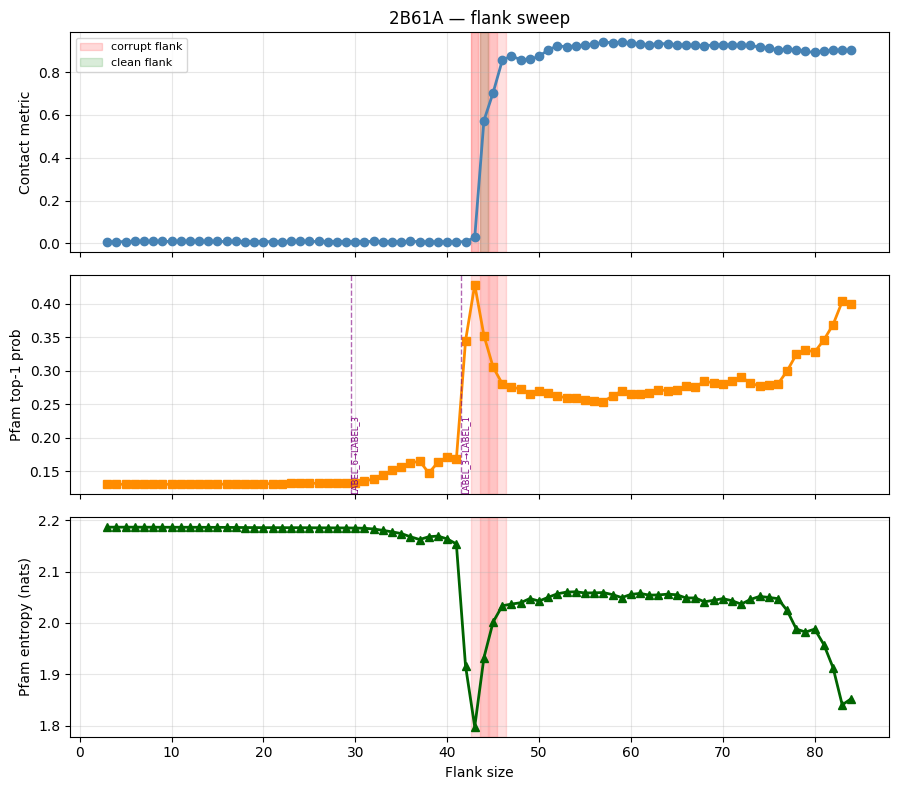

Saved to reports/outputs/2B61A_flank_sweep.png


In [6]:
# =============================================================================
# Flank sweep: contact metric + Pfam confidence side by side
# =============================================================================
# %%
import numpy as np

FLANK_START = config["corrupt_flank"] - 40
FLANK_END   = config["clean_flank"] + 40

results = []

print(f"\nFlank sweep for {protein} (contact pair {config['contact_pair']}):")
print(f"{'─'*75}")
print(f"  {'flank':>6}  {'contact':>9}  {'pfam_top1':>10}  {'pfam_p':>8}  {'entropy':>8}")
print(f"{'─'*75}")

for flank in range(FLANK_START, FLANK_END + 1):
    masked_seq_S = mask_with_flanks(sequence_S, segment, flank)
    
    # Contact metric
    contacts_AA  = compute_contact_map(esm_model, tokenizer, masked_seq_S, device)
    contact_val  = patching_metric(contacts_AA, orig_contacts_AA, segment)
    
    # Pfam classifier
    enc = pfam_tokenizer(masked_seq_S, return_tensors="pt", truncation=True, max_length=1022).to(device)
    with torch.no_grad():
        logits_C = pfam_model(**enc).logits[0]
    probs_C   = F.softmax(logits_C, dim=-1)
    top_prob, top_idx = probs_C.max(dim=-1)
    top_label = id2label[top_idx.item()]
    entropy   = (-probs_C * (probs_C + 1e-10).log()).sum().item()
    
    results.append({
        "flank":      flank,
        "contact":    contact_val,
        "pfam_label": top_label,
        "pfam_p":     top_prob.item(),
        "entropy":    entropy,
        "probs":      probs_C.cpu(),
    })
    
    print(f"  {flank:>6}  {contact_val:>9.4f}  {top_label:>10}  {top_prob.item():>8.4f}  {entropy:>8.3f}")

print(f"{'─'*75}")

# =============================================================================
# Jump detection: first-order differences
# =============================================================================
# %%
flanks        = np.array([r["flank"]   for r in results])
contact_vals  = np.array([r["contact"] for r in results])
pfam_probs    = np.array([r["pfam_p"]  for r in results])
entropies     = np.array([r["entropy"] for r in results])

contact_diff  = np.diff(contact_vals)   # positive = metric went up
pfam_diff     = np.diff(pfam_probs)     # positive = more confident
entropy_diff  = np.diff(entropies)      # negative = more confident (less entropy)

# Threshold: changes larger than 1.5× std
def find_jumps(arr: np.ndarray, flanks: np.ndarray, label: str, sign: int = 0) -> None:
    """sign: +1 = look for increases, -1 = look for decreases, 0 = either"""
    thresh = 1.5 * np.std(arr)
    if thresh == 0:
        print(f"  {label}: no variation detected")
        return
    candidates = np.where(np.abs(arr) > thresh)[0]
    if len(candidates) == 0:
        print(f"  {label}: no jumps above threshold ({thresh:.4f})")
        return
    for i in candidates:
        direction = "↑" if arr[i] > 0 else "↓"
        print(f"  {label}: {direction} {arr[i]:+.4f}  between flank {flanks[i]} → {flanks[i+1]}")

print("\nJump detection (threshold = 1.5σ of Δ):")
find_jumps(contact_diff, flanks, "contact metric ")
find_jumps(pfam_diff,    flanks, "pfam confidence")
find_jumps(entropy_diff, flanks, "pfam entropy   ")

# =============================================================================
# Plot
# =============================================================================
# %%
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

ax1, ax2, ax3 = axes

ax1.plot(flanks, contact_vals, "o-", color="steelblue", linewidth=2)
ax1.axvspan(config["corrupt_flank"] - 0.4, config["corrupt_flank"] + 0.4, alpha=0.15, color="red",   label="corrupt flank")
ax1.axvspan(config["clean_flank"]   - 0.4, config["clean_flank"]   + 0.4, alpha=0.15, color="green", label="clean flank")
ax1.set_ylabel("Contact metric")
ax1.set_title(f"{protein} — flank sweep")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(flanks, pfam_probs, "s-", color="darkorange", linewidth=2)
# mark label changes
for i in range(1, len(results)):
    if results[i]["pfam_label"] != results[i-1]["pfam_label"]:
        ax2.axvline(flanks[i] - 0.5, color="purple", linestyle="--", alpha=0.6, linewidth=1)
        ax2.text(flanks[i] - 0.5, ax2.get_ylim()[0], 
                 f"{results[i-1]['pfam_label']}→{results[i]['pfam_label']}", 
                 fontsize=6, rotation=90, va="bottom", color="purple")
ax2.set_ylabel("Pfam top-1 prob")
ax2.grid(True, alpha=0.3)

ax3.plot(flanks, entropies, "^-", color="darkgreen", linewidth=2)
ax3.set_ylabel("Pfam entropy (nats)")
ax3.set_xlabel("Flank size")
ax3.grid(True, alpha=0.3)

# Shade the jump region on all axes
for i, d in enumerate(contact_diff):
    if abs(d) > 1.5 * np.std(contact_diff):
        for ax in axes:
            ax.axvspan(flanks[i] - 0.4, flanks[i+1] + 0.4, alpha=0.12, color="red")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/{protein}_flank_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PLOT_DIR}/{protein}_flank_sweep.png")

In [7]:
# Compare per-label probability vectors between clean and corrupt using KL divergence
# If same features, the distribution shape should be similar even if top-1 differs

from torch.nn.functional import kl_div

def get_probs(seq):
    enc = pfam_tokenizer(seq, return_tensors="pt", truncation=True, max_length=1022).to(device)
    with torch.no_grad():
        return F.softmax(pfam_model(**enc).logits[0], dim=-1).cpu()

print("\nKL divergence of pfam distribution vs. original (full sequence):")
orig_probs = get_probs(sequence_S)

for r in results:
    masked_seq = mask_with_flanks(sequence_S, segment, r["flank"])
    p = get_probs(masked_seq)
    # KL(original || flank) — how far is the masked dist from the true dist
    kl = kl_div(p.log(), orig_probs, reduction="sum").item()
    print(f"  flank={r['flank']:3d}  contact={r['contact']:.3f}  KL_from_orig={kl:.4f}")


KL divergence of pfam distribution vs. original (full sequence):
  flank=  3  contact=0.007  KL_from_orig=0.3019
  flank=  4  contact=0.008  KL_from_orig=0.3018
  flank=  5  contact=0.008  KL_from_orig=0.3015
  flank=  6  contact=0.009  KL_from_orig=0.3008
  flank=  7  contact=0.009  KL_from_orig=0.3004
  flank=  8  contact=0.010  KL_from_orig=0.3000
  flank=  9  contact=0.010  KL_from_orig=0.2996
  flank= 10  contact=0.009  KL_from_orig=0.2990
  flank= 11  contact=0.010  KL_from_orig=0.2987
  flank= 12  contact=0.010  KL_from_orig=0.2987
  flank= 13  contact=0.010  KL_from_orig=0.2984
  flank= 14  contact=0.009  KL_from_orig=0.2978
  flank= 15  contact=0.009  KL_from_orig=0.2977
  flank= 16  contact=0.009  KL_from_orig=0.2975
  flank= 17  contact=0.009  KL_from_orig=0.2974
  flank= 18  contact=0.009  KL_from_orig=0.2969
  flank= 19  contact=0.008  KL_from_orig=0.2964
  flank= 20  contact=0.008  KL_from_orig=0.2955
  flank= 21  contact=0.008  KL_from_orig=0.2950
  flank= 22  contact=0

In [ ]:
# =============================================================================
# Pfam Probe — Train on full sequences, test with mean-ablation (not masking)
# Strategy: Option A — fixes the OOD problem at test time
# =============================================================================

# ── 0. Imports ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
import pickle, os

PROBE_CACHE_DIR = "reports/cache/probe"
os.makedirs(PROBE_CACHE_DIR, exist_ok=True)

In [15]:
# =============================================================================
# 1. Data — confirmed working slug
# =============================================================================
print("Loading Pfam dataset...")
ds = load_dataset("DanielHesslow/SwissProt-Pfam")
print(ds)
print("Sample:", ds["train"][0])

# ── Schema notes ──────────────────────────────────────────────────────────────
# ds["train"][0] looks like:
#   seq:        "MSKIIE..."
#   labels:     [4358]           ← integer indices into idx_mapping.json
#   labels_str: ['Pfam:PF00118'] ← the actual Pfam accessions
#   id:         "P60545"         ← UniProt accession

# Multi-label: a protein can have multiple Pfam domains.
# For a simple single-label probe, take the FIRST label only.
# For multi-label, you'd need BCELoss instead of CrossEntropy.
# We use single-label (first domain) for simplicity.

# ── Filter to single-domain proteins and top-K families ──────────────────────
K_FAMILIES = 100
N_TRAIN, N_VAL, N_TEST = 5_000, 500, 500

def get_primary_label(row):
    """Return first Pfam accession, stripping the 'Pfam:' prefix."""
    if not row["labels_str"]:
        return None
    return row["labels_str"][0].replace("Pfam:", "")

# Count family frequency in train
from collections import Counter
family_counts = Counter(
    get_primary_label(r) for r in ds["train"] if get_primary_label(r)
)
top_families = {fam for fam, _ in family_counts.most_common(K_FAMILIES)}
print(f"\nTop {K_FAMILIES} families cover "
      f"{sum(c for f,c in family_counts.items() if f in top_families)} / "
      f"{len(ds['train'])} train sequences")

def filter_split(split_name, n):
    rows = []
    for r in ds[split_name]:
        label = get_primary_label(r)
        if label and label in top_families and r["seq"]:
            rows.append({"sequence": r["seq"], "family_accession": label})
    np.random.shuffle(rows)
    return rows[:n]

np.random.seed(42)
train_rows = filter_split("train", N_TRAIN)
val_rows   = filter_split("dev",   N_VAL)
test_rows  = filter_split("test",  N_TEST)

le = LabelEncoder()
le.fit([r["family_accession"] for r in train_rows])

# Filter val/test to families seen in train (LabelEncoder can't handle unseen)
val_rows  = [r for r in val_rows  if r["family_accession"] in le.classes_]
test_rows = [r for r in test_rows if r["family_accession"] in le.classes_]

train_seqs   = [r["sequence"] for r in train_rows]
train_labels = le.transform([r["family_accession"] for r in train_rows])
val_seqs     = [r["sequence"] for r in val_rows]
val_labels   = le.transform([r["family_accession"] for r in val_rows])
test_seqs    = [r["sequence"] for r in test_rows]
test_labels  = le.transform([r["family_accession"] for r in test_rows])

print(f"\nDataset ready:")
print(f"  Train: {len(train_seqs)} seqs, {len(le.classes_)} families")
print(f"  Val:   {len(val_seqs)} seqs")
print(f"  Test:  {len(test_seqs)} seqs")

# Check if 2B61A's family (P45131) is in the label set
# P45131 is a flavodoxin-like fold — likely PF00258 (Flavodoxin_1)
# We'll check after embedding by looking up which family the probe assigns to sequence_S


Loading Pfam dataset...


README.md:   0%|          | 0.00/494 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/149M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/409267 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50530 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/51557 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['seq', 'labels', 'labels_str', 'id'],
        num_rows: 409267
    })
    test: Dataset({
        features: ['seq', 'labels', 'labels_str', 'id'],
        num_rows: 50530
    })
    dev: Dataset({
        features: ['seq', 'labels', 'labels_str', 'id'],
        num_rows: 51557
    })
})
Sample: {'seq': 'MSKIIEYDETARRAIEAGVNTLADAVRVTLGPRGRHVVLAKAFGGPAVTNDGVTVAREIDLEDPFENLGAQLVKSVATKTNDVAGDGTTTATVLAQALVKGGLRLVAAGANPIELGAGISKAADAVSEALLASATPVSGKDAIAQVATVSSRDQVLGELVGEAMTKVGVDGVVSVEESSTLNTELEFTEGVGFDKGFLSAYFVTDFDAQQAVLDDPVILLHQEKISSLPDLLPMLEKVAESGKPLLIIAEDIEGEALATLVVNSIRKTLKAVAVKAPFFGDRRKAFLEDLAIVTGGQVINPDTGLLLREVGTEVLGSARRVVVSKDDTIIVDGGGAKDAVANRIKQLRAEIEKTDSDWDREKLQERLAKLAGGVAVIKVGAATETALKERKESVEDAVAAAKAAVEEGIVAGGGSALLQARKALDELRGSLSGDQALGVDVFAEALGAPLYWIASNAGLDGAVAVHKVAELPAGHGLNAEKLSYGDLIADGVIDPVKVTRSAVLNSASVARMVLTTETAVVDKPAEEADDHGHGHHHH', 'labels': [4358], 'labels_str': "['Pfam:PF00118']", 'id': 'P60545'}

Top 100 families cover 409267 /

In [17]:

# =============================================================================
# 2. Embedding extraction — frozen ESM2, mean pool over last hidden state
# =============================================================================
# %%
def extract_embeddings(
    sequences: list[str],
    model,
    tok,
    device: str,
    batch_size: int = 8,
    layer: int = -1,        # -1 = last layer; change to probe specific layers
    cache_path: str | None = None,
) -> np.ndarray:
    """
    Extract mean-pooled ESM2 embeddings for a list of sequences.
    Returns array of shape (N, hidden_dim).
    Uses cache if available.
    """
    if cache_path and os.path.exists(cache_path):
        print(f"  Loading embeddings from cache: {cache_path}")
        return np.load(cache_path)

    model.eval()
    all_embs = []

    for i in range(0, len(sequences), batch_size):
        batch = sequences[i : i + batch_size]
        enc = tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1022,
        ).to(device)

        with torch.no_grad():
            out = model.esm(**enc, output_hidden_states=True)
            # hidden_states: tuple of (n_layers+1) tensors, each [B, L, D]
            h = out.hidden_states[layer]   # [B, L, D]

        # Mean pool — exclude BOS/EOS tokens (positions 0 and -1)
        mask = enc["attention_mask"][:, 1:-1].unsqueeze(-1).float()
        h_inner = h[:, 1:-1, :]                             # [B, L-2, D]
        pooled  = (h_inner * mask).sum(1) / mask.sum(1)     # [B, D]
        all_embs.append(pooled.cpu().float().numpy())

        if (i // batch_size) % 10 == 0:
            print(f"  Embedded {min(i+batch_size, len(sequences))}/{len(sequences)}", end="\r")

    print()
    embs = np.concatenate(all_embs, axis=0)
    if cache_path:
        np.save(cache_path, embs)
        print(f"  Saved embeddings to {cache_path}")
    return embs


print("\nExtracting embeddings (this takes a few minutes on GPU)...")
train_embs = extract_embeddings(train_seqs, esm_model, tokenizer, device,
                                 cache_path=f"{PROBE_CACHE_DIR}/train_embs.npy")
val_embs   = extract_embeddings(val_seqs,   esm_model, tokenizer, device,
                                 cache_path=f"{PROBE_CACHE_DIR}/val_embs.npy")
test_embs  = extract_embeddings(test_seqs,  esm_model, tokenizer, device,
                                 cache_path=f"{PROBE_CACHE_DIR}/test_embs.npy")

# =============================================================================
# 3. Train linear probe (sklearn — fast, interpretable coefficients)
# =============================================================================
# %%
print("\nTraining linear probe...")
probe = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    n_jobs=-1,
    verbose=1,
)
probe.fit(train_embs, train_labels)

val_preds  = probe.predict(val_embs)
test_preds = probe.predict(test_embs)

val_acc  = accuracy_score(val_labels,  val_preds)
test_acc = accuracy_score(test_labels, test_preds)

print(f"\nProbe accuracy:")
print(f"  Val:  {val_acc:.4f}")
print(f"  Test: {test_acc:.4f}")
print("\nPer-family breakdown (test):")
print(classification_report(
    test_labels, test_preds,
    target_names=le.classes_[:10],  # print first 10 families only
    labels=list(range(min(10, len(le.classes_)))),
))

# Save probe + label encoder
with open(f"{PROBE_CACHE_DIR}/probe.pkl", "wb") as f:
    pickle.dump({"probe": probe, "le": le}, f)
print(f"Probe saved to {PROBE_CACHE_DIR}/probe.pkl")

# =============================================================================
# 4. Test-time: mean ablation instead of <mask> tokens
# =============================================================================
# This is the key fix over the previous experiment.
# Instead of replacing non-flank residues with <mask>,
# we extract embeddings normally then zero/mean-ablate
# the hidden states at non-flank positions before pooling.
# %%

def get_mean_activation(model, tok, device, n_seqs: int = 100) -> torch.Tensor:
    """Estimate mean hidden state across a sample of real sequences."""
    cache = f"{PROBE_CACHE_DIR}/mean_activation.pt"
    if os.path.exists(cache):
        return torch.load(cache)

    sample = train_seqs[:n_seqs]
    all_h  = []
    for seq in sample:
        enc = tok(seq, return_tensors="pt", truncation=True, max_length=1022).to(device)
        with torch.no_grad():
            out = esm_model.esm(**enc, output_hidden_states=True)
        all_h.append(out.hidden_states[-1][0, 1:-1].cpu())  # exclude BOS/EOS
    mean_act = torch.cat(all_h, dim=0).mean(0)              # [D]
    torch.save(mean_act, cache)
    return mean_act

print("\nComputing mean activation for ablation baseline...")
mean_act_D = get_mean_activation(esm_model, tokenizer, device).to(device)

def probe_with_mean_ablation(
    sequence_S:  str,
    segment:     ContactSegment,
    flank_size:  int,
    mean_act_D:  torch.Tensor,
) -> tuple[str, float, float]:
    """
    Run Pfam probe on a sequence where non-flank positions are mean-ablated.
    Returns (predicted_family, top_prob, entropy).
    
    Unlike masking, this keeps the sequence in-distribution:
    the model sees real tokens everywhere, but we replace the
    non-flank hidden states with the mean before pooling.
    """
    enc = tokenizer(sequence_S, return_tensors="pt",
                    truncation=True, max_length=1022).to(device)
    seq_len = enc["input_ids"].shape[1]   # includes BOS/EOS

    # Build a boolean mask: True = keep this position's hidden state
    # Offset by 1 for BOS token
    keep = torch.zeros(seq_len, dtype=torch.bool, device=device)
    
    # Flank positions (convert sequence indices → token indices with +1 for BOS)
    regions = [
        range(max(0, segment.ss1_start - flank_size), segment.ss1_end + flank_size),
        range(max(0, segment.ss2_start - flank_size), segment.ss2_end + flank_size),
    ]
    for rng in regions:
        for pos in rng:
            tok_pos = pos + 1   # +1 for BOS
            if tok_pos < seq_len - 1:   # exclude EOS
                keep[tok_pos] = True

    with torch.no_grad():
        out = esm_model.esm(**enc, output_hidden_states=True)
        h_BLD = out.hidden_states[-1]   # [1, L, D]
        h_LD  = h_BLD[0]               # [L, D]

        # Ablate non-flank positions with mean activation
        ablated_LD = h_LD.clone()
        ablated_LD[~keep] = mean_act_D

        # Mean pool over kept positions only (excluding BOS/EOS)
        inner_keep = keep[1:-1]   # [L-2]
        h_inner    = ablated_LD[1:-1]   # [L-2, D]
        
        if inner_keep.sum() == 0:
            # No residues kept — use pure mean activation
            pooled_D = mean_act_D.unsqueeze(0)
        else:
            pooled_D = h_inner[inner_keep].mean(0, keepdim=True)   # [1, D]

    # Run through probe
    pooled_np = pooled_D.cpu().float().numpy()
    probs     = probe.predict_proba(pooled_np)[0]
    top_idx   = probs.argmax()
    entropy   = -(probs * np.log(probs + 1e-10)).sum()

    return le.classes_[top_idx], probs[top_idx], entropy


# =============================================================================
# 5. Flank sweep with mean ablation — the clean version of the original experiment
# =============================================================================
# %%
# First: what family does the full sequence belong to?
full_emb   = extract_embeddings([sequence_S], esm_model, tokenizer, device)
full_pred  = le.classes_[probe.predict(full_emb)[0]]
full_prob  = probe.predict_proba(full_emb)[0].max()

print(f"\nFull sequence prediction: {full_pred}  (p={full_prob:.4f})")
print(f"(Check against actual Pfam label for {protein} from UniProt)")

print(f"\nFlank sweep with mean ablation (no mask tokens):")
print(f"{'─'*70}")
print(f"  {'flank':>6}  {'contact':>9}  {'pfam_fam':>12}  {'pfam_p':>8}  {'entropy':>8}")
print(f"{'─'*70}")

ablation_results = []
for flank in range(FLANK_START, FLANK_END + 1):
    # Contact metric — still uses masked sequence (that's fine, contact head trained on real seqs)
    masked_seq  = mask_with_flanks(sequence_S, segment, flank)
    contacts_AA = compute_contact_map(esm_model, tokenizer, masked_seq, device)
    contact_val = patching_metric(contacts_AA, orig_contacts_AA, segment)

    # Pfam probe — uses mean ablation on full sequence
    pfam_fam, pfam_p, entropy = probe_with_mean_ablation(
        sequence_S, segment, flank, mean_act_D
    )

    ablation_results.append({
        "flank": flank, "contact": contact_val,
        "pfam_fam": pfam_fam, "pfam_p": pfam_p, "entropy": entropy,
    })
    print(f"  {flank:>6}  {contact_val:>9.4f}  {pfam_fam:>12}  {pfam_p:>8.4f}  {entropy:>8.3f}")

print(f"{'─'*70}")
print(f"\nGround truth (full seq): {full_pred}")
correct_at_contact_jump = [
    r for r in ablation_results
    if r["contact"] > 0.3 and r["pfam_fam"] == full_pred
]
print(f"Probe predicts correct family at contact-recovering flanks: "
      f"{len(correct_at_contact_jump)}/{sum(1 for r in ablation_results if r['contact'] > 0.3)}")


Extracting embeddings (this takes a few minutes on GPU)...
  Loading embeddings from cache: reports/cache/probe/train_embs.npy
  Loading embeddings from cache: reports/cache/probe/val_embs.npy
  Loading embeddings from cache: reports/cache/probe/test_embs.npy

Training linear probe...


/home/jnainani_umass_edu/p/plm_nnsight/.plm_nn/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

In [18]:
# Debug: check what's actually in train_labels
print(f"train_labels unique values: {np.unique(train_labels)}")
print(f"train_rows family distribution (top 10):")
from collections import Counter
fam_counts = Counter(r["family_accession"] for r in train_rows)
for fam, cnt in fam_counts.most_common(10):
    print(f"  {fam}: {cnt}")
print(f"le.classes_: {le.classes_[:10]}")

train_labels unique values: [0]
train_rows family distribution (top 10):
  [: 5000
le.classes_: ['[']


Loading Pfam dataset...
DatasetDict({
    train: Dataset({
        features: ['seq', 'labels', 'labels_str', 'id'],
        num_rows: 409267
    })
    test: Dataset({
        features: ['seq', 'labels', 'labels_str', 'id'],
        num_rows: 50530
    })
    dev: Dataset({
        features: ['seq', 'labels', 'labels_str', 'id'],
        num_rows: 51557
    })
})

Schema check:
  raw labels_str : "['Pfam:PF00118']"
  parsed label   : PF00118
  seq[:40]       : MSKIIEYDETARRAIEAGVNTLADAVRVTLGPRGRHVVLA

Counting families...
Top 100 families: ['PF00001', 'PF00004', 'PF00005', 'PF00006', 'PF00009'] ...
Cover 89879 / 409267 train sequences

LabelEncoder: 100 classes, e.g. ['PF00001' 'PF00004' 'PF00005' 'PF00006' 'PF00009']

Dataset ready:
  Train : 5000 seqs, 100 unique families
  Val   : 500 seqs
  Test  : 500 seqs
  Cleared old cache: reports/cache/probe/train_embs.npy
  Cleared old cache: reports/cache/probe/val_embs.npy
  Cleared old cache: reports/cache/probe/test_embs.npy

Extracting 

/home/jnainani_umass_edu/p/plm_nnsight/.plm_nn/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Probe accuracy:
  Val  : 0.9860
  Test : 0.9840

Per-family (first 10 families, test):
              precision    recall  f1-score   support

     PF00001       1.00      1.00      1.00         6
     PF00004       1.00      1.00      1.00        11
     PF00005       1.00      1.00      1.00        15
     PF00006       1.00      1.00      1.00        11
     PF00009       1.00      1.00      1.00        10
     PF00012       1.00      1.00      1.00         1
     PF00013       1.00      0.67      0.80         6
     PF00032       1.00      1.00      1.00         6
     PF00042       1.00      1.00      1.00         6
     PF00046       1.00      1.00      1.00         2

   micro avg       1.00      0.97      0.99        74
   macro avg       1.00      0.97      0.98        74
weighted avg       1.00      0.97      0.98        74

Probe saved.

Computing mean activation...
  Mean activation shape: torch.Size([1280])
  1/1

Full sequence (2B61A) prediction: PF01979  (p=0.0830)
  → C

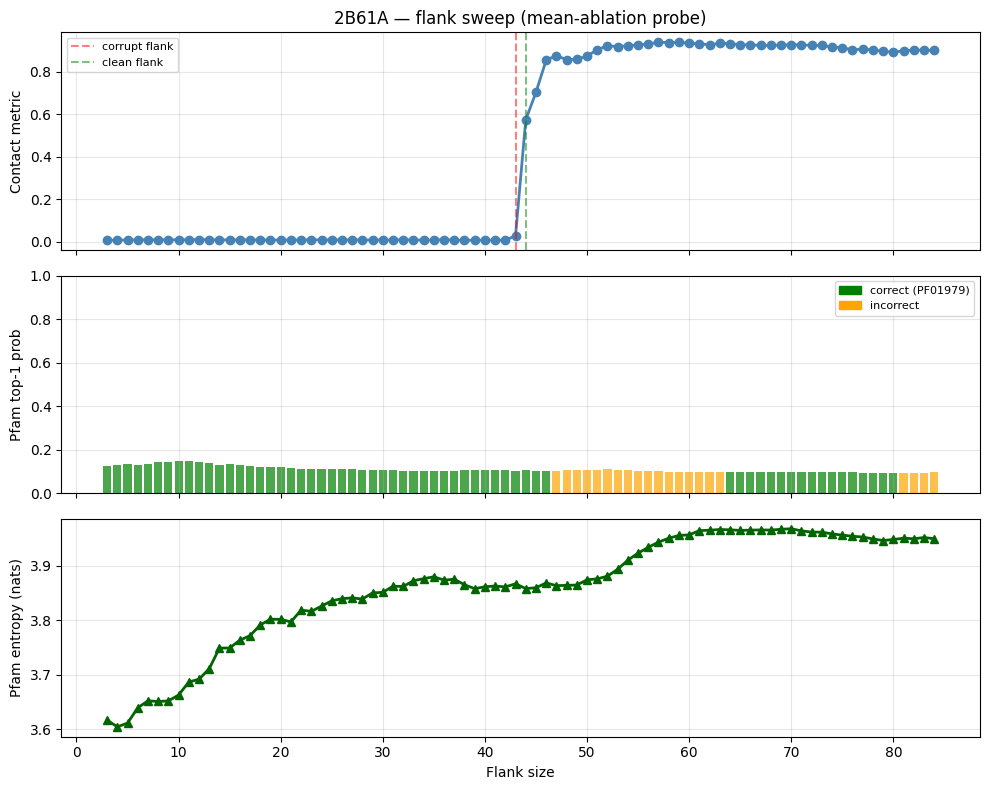


Saved to reports/outputs/2B61A_ablation_sweep.png


In [19]:
# =============================================================================
# Pfam Probe — full script
# Train on SwissProt-Pfam, test with mean-ablation (no mask OOD issue)
# =============================================================================
from __future__ import annotations
import ast, os, pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from transformers import EsmForMaskedLM, EsmTokenizer
from nnsight import NNsight

# ── reuse from your existing notebook ────────────────────────────────────────
# These must already be defined in your session:
#   esm_model, tokenizer, device, sequence_S, segment,
#   orig_contacts_AA, PROTEINS, protein, FLANK_START, FLANK_END
#   compute_contact_map, patching_metric, mask_with_flanks, ContactSegment
# ─────────────────────────────────────────────────────────────────────────────

PROBE_CACHE_DIR = "reports/cache/probe"
PLOT_DIR        = "reports/outputs"
os.makedirs(PROBE_CACHE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

K_FAMILIES       = 100
N_TRAIN          = 5_000
N_VAL            =   500
N_TEST           =   500

# =============================================================================
# 1. Data
# =============================================================================
print("Loading Pfam dataset...")
ds = load_dataset("DanielHesslow/SwissProt-Pfam")
print(ds)

# labels_str is stored as a stringified list e.g. "['Pfam:PF00118']"
def get_primary_label(row) -> str | None:
    raw = row["labels_str"]
    if not raw:
        return None
    if isinstance(raw, str):
        try:
            raw = ast.literal_eval(raw)
        except Exception:
            return None
    if not raw:
        return None
    return raw[0].replace("Pfam:", "")

# Sanity check on first row
sample = ds["train"][0]
print(f"\nSchema check:")
print(f"  raw labels_str : {repr(sample['labels_str'])}")
print(f"  parsed label   : {get_primary_label(sample)}")
print(f"  seq[:40]       : {sample['seq'][:40]}")

# Count families on full train set before sampling
print("\nCounting families...")
all_train_rows = []
for r in ds["train"]:
    label = get_primary_label(r)
    if label and r["seq"]:
        all_train_rows.append({"sequence": r["seq"], "family_accession": label})

family_counts = Counter(r["family_accession"] for r in all_train_rows)
top_families  = {fam for fam, _ in family_counts.most_common(K_FAMILIES)}
print(f"Top {K_FAMILIES} families: {sorted(top_families)[:5]} ...")
print(f"Cover {sum(c for f,c in family_counts.items() if f in top_families)} / "
      f"{len(all_train_rows)} train sequences")

# Filter and sample
np.random.seed(42)
all_train_filtered = [r for r in all_train_rows if r["family_accession"] in top_families]
np.random.shuffle(all_train_filtered)
train_rows = all_train_filtered[:N_TRAIN]

def get_rows_from_split(split_name: str, n: int) -> list[dict]:
    rows = []
    for r in ds[split_name]:
        label = get_primary_label(r)
        if label and label in top_families and r["seq"]:
            rows.append({"sequence": r["seq"], "family_accession": label})
    np.random.shuffle(rows)
    return rows[:n]

val_rows  = get_rows_from_split("dev",  N_VAL)
test_rows = get_rows_from_split("test", N_TEST)

# Fit label encoder on train families
le = LabelEncoder()
le.fit([r["family_accession"] for r in train_rows])
print(f"\nLabelEncoder: {len(le.classes_)} classes, e.g. {le.classes_[:5]}")

# Filter val/test to seen families
val_rows  = [r for r in val_rows  if r["family_accession"] in le.classes_]
test_rows = [r for r in test_rows if r["family_accession"] in le.classes_]

train_seqs   = [r["sequence"] for r in train_rows]
train_labels = le.transform([r["family_accession"] for r in train_rows])
val_seqs     = [r["sequence"] for r in val_rows]
val_labels   = le.transform([r["family_accession"] for r in val_rows])
test_seqs    = [r["sequence"] for r in test_rows]
test_labels  = le.transform([r["family_accession"] for r in test_rows])

print(f"\nDataset ready:")
print(f"  Train : {len(train_seqs)} seqs, {len(np.unique(train_labels))} unique families")
print(f"  Val   : {len(val_seqs)} seqs")
print(f"  Test  : {len(test_seqs)} seqs")

# =============================================================================
# 2. Embedding extraction
# =============================================================================
def extract_embeddings(
    sequences : list[str],
    model,
    tok,
    device    : str,
    batch_size: int = 8,
    layer     : int = -1,
    cache_path: str | None = None,
) -> np.ndarray:
    """Mean-pool ESM2 hidden states (excludes BOS/EOS). Caches to disk."""
    if cache_path and os.path.exists(cache_path):
        print(f"  Loading from cache: {cache_path}")
        return np.load(cache_path)

    model.eval()
    all_embs = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i : i + batch_size]
        enc = tok(batch, return_tensors="pt", padding=True,
                  truncation=True, max_length=1022).to(device)
        with torch.no_grad():
            out = model.esm(**enc, output_hidden_states=True)
            h   = out.hidden_states[layer]          # [B, L, D]
        mask   = enc["attention_mask"][:, 1:-1].unsqueeze(-1).float()
        h_inner = h[:, 1:-1, :]                     # [B, L-2, D]
        pooled  = (h_inner * mask).sum(1) / mask.sum(1)  # [B, D]
        all_embs.append(pooled.cpu().float().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  {min(i+batch_size, len(sequences))}/{len(sequences)}", end="\r")
    print()
    embs = np.concatenate(all_embs, axis=0)
    if cache_path:
        np.save(cache_path, embs)
        print(f"  Saved to {cache_path}")
    return embs

# Delete old caches if sequences changed
for f in ["train_embs.npy", "val_embs.npy", "test_embs.npy"]:
    p = f"{PROBE_CACHE_DIR}/{f}"
    if os.path.exists(p):
        os.remove(p)
        print(f"  Cleared old cache: {p}")

print("\nExtracting embeddings...")
train_embs = extract_embeddings(train_seqs, esm_model, tokenizer, device,
                                cache_path=f"{PROBE_CACHE_DIR}/train_embs.npy")
val_embs   = extract_embeddings(val_seqs,   esm_model, tokenizer, device,
                                cache_path=f"{PROBE_CACHE_DIR}/val_embs.npy")
test_embs  = extract_embeddings(test_seqs,  esm_model, tokenizer, device,
                                cache_path=f"{PROBE_CACHE_DIR}/test_embs.npy")

# =============================================================================
# 3. Train linear probe
# =============================================================================
print("\nTraining linear probe...")
probe = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    n_jobs=-1,
    verbose=1,
)
probe.fit(train_embs, train_labels)

val_preds  = probe.predict(val_embs)
test_preds = probe.predict(test_embs)
val_acc    = accuracy_score(val_labels,  val_preds)
test_acc   = accuracy_score(test_labels, test_preds)

print(f"\nProbe accuracy:")
print(f"  Val  : {val_acc:.4f}")
print(f"  Test : {test_acc:.4f}")
print("\nPer-family (first 10 families, test):")
print(classification_report(
    test_labels, test_preds,
    target_names=le.classes_[:10],
    labels=list(range(min(10, len(le.classes_)))),
    zero_division=0,
))

with open(f"{PROBE_CACHE_DIR}/probe.pkl", "wb") as f:
    pickle.dump({"probe": probe, "le": le}, f)
print(f"Probe saved.")

# =============================================================================
# 4. Mean activation (for ablation baseline)
# =============================================================================
def get_mean_activation(model, tok, device, n_seqs: int = 100) -> torch.Tensor:
    cache = f"{PROBE_CACHE_DIR}/mean_activation.pt"
    if os.path.exists(cache):
        print(f"  Loading mean activation from cache.")
        return torch.load(cache, weights_only=True)
    model.eval()
    all_h = []
    for seq in train_seqs[:n_seqs]:
        enc = tok(seq, return_tensors="pt", truncation=True, max_length=1022).to(device)
        with torch.no_grad():
            out = model.esm(**enc, output_hidden_states=True)
        all_h.append(out.hidden_states[-1][0, 1:-1].cpu())   # [L-2, D]
    mean_act = torch.cat(all_h, dim=0).mean(0)               # [D]
    torch.save(mean_act, cache)
    print(f"  Mean activation shape: {mean_act.shape}")
    return mean_act

print("\nComputing mean activation...")
mean_act_D = get_mean_activation(esm_model, tokenizer, device).to(device)

# =============================================================================
# 5. Probe with mean ablation (the clean test-time approach)
# =============================================================================
def probe_with_mean_ablation(
    sequence_S : str,
    segment    : ContactSegment,
    flank_size : int,
    mean_act_D : torch.Tensor,
) -> tuple[str, float, float]:
    """
    Run full sequence through ESM2, then mean-ablate non-flank hidden states
    before pooling. Probe never sees mask tokens → no OOD issue.
    Returns (predicted_family, top_prob, entropy).
    """
    enc     = tokenizer(sequence_S, return_tensors="pt",
                        truncation=True, max_length=1022).to(device)
    seq_len = enc["input_ids"].shape[1]   # includes BOS + EOS

    # Which token positions to KEEP (flank + contact segments, 1-indexed for BOS)
    keep = torch.zeros(seq_len, dtype=torch.bool, device=device)
    regions = [
        range(max(0, segment.ss1_start - flank_size), segment.ss1_end + flank_size),
        range(max(0, segment.ss2_start - flank_size), segment.ss2_end + flank_size),
    ]
    for rng in regions:
        for pos in rng:
            tok_pos = pos + 1              # +1 for BOS
            if tok_pos < seq_len - 1:     # exclude EOS
                keep[tok_pos] = True

    with torch.no_grad():
        out    = esm_model.esm(**enc, output_hidden_states=True)
        h_LD   = out.hidden_states[-1][0]              # [L, D]
        ablated = h_LD.clone()
        ablated[~keep] = mean_act_D                    # ablate non-flank positions

        inner_keep = keep[1:-1]                        # [L-2], exclude BOS/EOS
        h_inner    = ablated[1:-1]                     # [L-2, D]
        if inner_keep.sum() == 0:
            pooled_D = mean_act_D.unsqueeze(0)
        else:
            pooled_D = h_inner[inner_keep].mean(0, keepdim=True)  # [1, D]

    probs   = probe.predict_proba(pooled_D.cpu().float().numpy())[0]
    top_idx = probs.argmax()
    entropy = -(probs * np.log(probs + 1e-10)).sum()
    return le.classes_[top_idx], probs[top_idx], entropy

# =============================================================================
# 6. Full-sequence prediction for 2B61A
# =============================================================================
full_emb  = extract_embeddings([sequence_S], esm_model, tokenizer, device)
full_pred = le.classes_[probe.predict(full_emb)[0]]
full_prob = probe.predict_proba(full_emb)[0].max()
print(f"\nFull sequence ({protein}) prediction: {full_pred}  (p={full_prob:.4f})")
print(f"  → Check this against P45131 on UniProt/InterPro")
print(f"  → Expected family is likely PF00258 (Flavodoxin_1) or similar")

# =============================================================================
# 7. Flank sweep with mean ablation
# =============================================================================
print(f"\nFlank sweep: {protein}, flanks {FLANK_START}..{FLANK_END}")
print(f"{'─'*72}")
print(f"  {'flank':>6}  {'contact':>9}  {'pfam_fam':>12}  {'pfam_p':>8}  {'entropy':>8}  correct")
print(f"{'─'*72}")

ablation_results = []
for flank in range(FLANK_START, FLANK_END + 1):
    # Contact metric (masked sequence, as before)
    masked_seq  = mask_with_flanks(sequence_S, segment, flank)
    contacts_AA = compute_contact_map(esm_model, tokenizer, masked_seq, device)
    contact_val = patching_metric(contacts_AA, orig_contacts_AA, segment)

    # Pfam probe (mean-ablated full sequence)
    pfam_fam, pfam_p, entropy = probe_with_mean_ablation(
        sequence_S, segment, flank, mean_act_D
    )
    correct = "✓" if pfam_fam == full_pred else "✗"

    ablation_results.append({
        "flank": flank, "contact": contact_val,
        "pfam_fam": pfam_fam, "pfam_p": pfam_p,
        "entropy": entropy, "correct": pfam_fam == full_pred,
    })
    print(f"  {flank:>6}  {contact_val:>9.4f}  {pfam_fam:>12}  "
          f"{pfam_p:>8.4f}  {entropy:>8.3f}  {correct}")

print(f"{'─'*72}")

# Summary
contact_jump_flanks = [r for r in ablation_results if r["contact"] > 0.3]
correct_at_jump     = [r for r in contact_jump_flanks if r["correct"]]
print(f"\nGround truth (full seq): {full_pred}")
print(f"Correct family when contact > 0.3: "
      f"{len(correct_at_jump)}/{len(contact_jump_flanks)}")

# Jump detection
flanks       = np.array([r["flank"]   for r in ablation_results])
contact_vals = np.array([r["contact"] for r in ablation_results])
pfam_probs   = np.array([r["pfam_p"]  for r in ablation_results])
contact_diff = np.diff(contact_vals)
pfam_diff    = np.diff(pfam_probs)

print("\nJump detection (1.5σ threshold):")
for label, arr in [("contact", contact_diff), ("pfam_p", pfam_diff)]:
    thresh = 1.5 * np.std(arr)
    for i in np.where(np.abs(arr) > thresh)[0]:
        d = "↑" if arr[i] > 0 else "↓"
        print(f"  {label}: {d} {arr[i]:+.4f}  flank {flanks[i]} → {flanks[i+1]}")

# =============================================================================
# 8. Plot
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax1, ax2, ax3 = axes

ax1.plot(flanks, contact_vals, "o-", color="steelblue", lw=2)
ax1.axvline(PROTEINS[protein]["corrupt_flank"], color="red",   ls="--", alpha=0.5, label="corrupt flank")
ax1.axvline(PROTEINS[protein]["clean_flank"],   color="green", ls="--", alpha=0.5, label="clean flank")
ax1.set_ylabel("Contact metric")
ax1.set_title(f"{protein} — flank sweep (mean-ablation probe)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

correct_arr = np.array([r["correct"] for r in ablation_results])
colors = ["green" if c else "orange" for c in correct_arr]
ax2.bar(flanks, pfam_probs, color=colors, alpha=0.7, label="correct=green")
ax2.set_ylabel("Pfam top-1 prob")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color="green",  label=f"correct ({full_pred})"),
    Patch(color="orange", label="incorrect"),
], fontsize=8)

entropies = np.array([r["entropy"] for r in ablation_results])
ax3.plot(flanks, entropies, "^-", color="darkgreen", lw=2)
ax3.set_ylabel("Pfam entropy (nats)")
ax3.set_xlabel("Flank size")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
outpath = f"{PLOT_DIR}/{protein}_ablation_sweep.png"
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved to {outpath}")

  1/1

Full sequence (2B61A) prediction: PF01979  (p=0.0830)
  → Check this against P45131 on UniProt/InterPro
  → Expected family is likely PF00258 (Flavodoxin_1) or similar

Flank sweep: 2B61A, flanks 30..100
────────────────────────────────────────────────────────────────────────
   flank    contact      pfam_fam    pfam_p   entropy  correct
────────────────────────────────────────────────────────────────────────
      30     0.0086       PF01979    0.1082     3.851  ✓
      31     0.0087       PF01979    0.1060     3.862  ✓
      32     0.0093       PF01979    0.1047     3.862  ✓
      33     0.0088       PF01979    0.1036     3.872  ✓
      34     0.0080       PF01979    0.1043     3.876  ✓
      35     0.0080       PF01979    0.1021     3.879  ✓
      36     0.0103       PF01979    0.1039     3.873  ✓
      37     0.0081       PF01979    0.1047     3.875  ✓
      38     0.0073       PF01979    0.1067     3.865  ✓
      39     0.0075       PF01979    0.1081     3.858  ✓
      40  

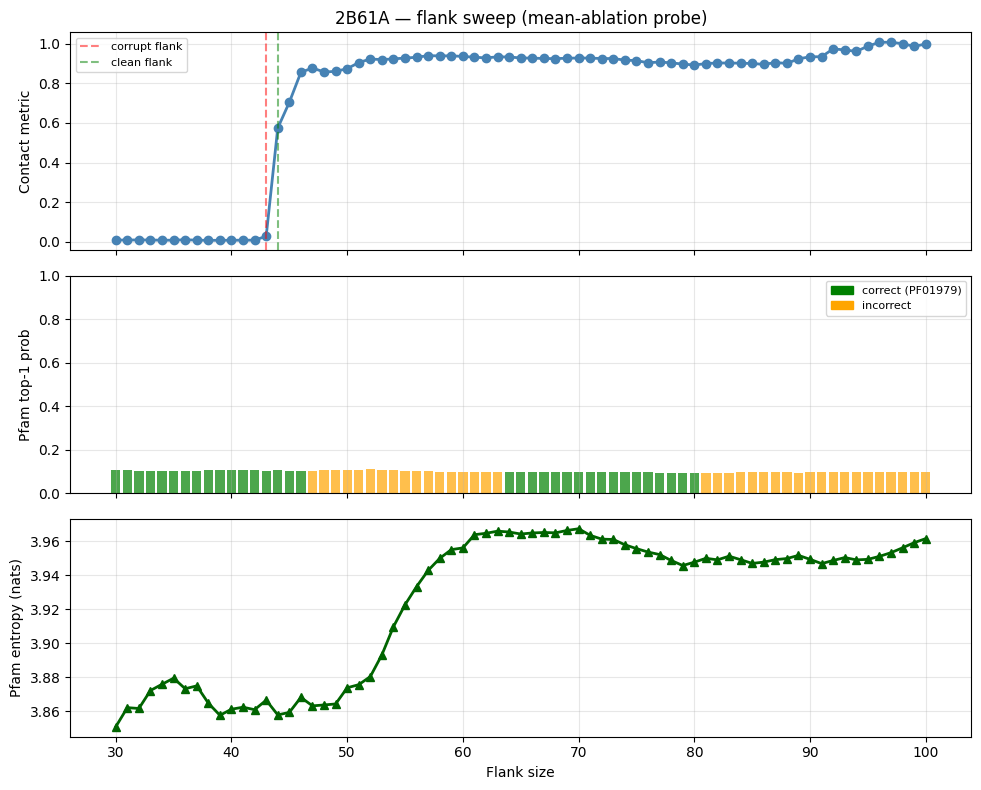


Saved to reports/outputs/2B61A_ablation_sweep.png


In [21]:

# =============================================================================
# 6. Full-sequence prediction for 2B61A
# =============================================================================
full_emb  = extract_embeddings([sequence_S], esm_model, tokenizer, device)
full_pred = le.classes_[probe.predict(full_emb)[0]]
full_prob = probe.predict_proba(full_emb)[0].max()
print(f"\nFull sequence ({protein}) prediction: {full_pred}  (p={full_prob:.4f})")
print(f"  → Check this against P45131 on UniProt/InterPro")
print(f"  → Expected family is likely PF00258 (Flavodoxin_1) or similar")

# =============================================================================
# 7. Flank sweep with mean ablation
# =============================================================================
FLANK_START = 30
FLANK_END   = 100
print(f"\nFlank sweep: {protein}, flanks {FLANK_START}..{FLANK_END}")
print(f"{'─'*72}")
print(f"  {'flank':>6}  {'contact':>9}  {'pfam_fam':>12}  {'pfam_p':>8}  {'entropy':>8}  correct")
print(f"{'─'*72}")

ablation_results = []
for flank in range(FLANK_START, FLANK_END + 1):
    # Contact metric (masked sequence, as before)
    masked_seq  = mask_with_flanks(sequence_S, segment, flank)
    contacts_AA = compute_contact_map(esm_model, tokenizer, masked_seq, device)
    contact_val = patching_metric(contacts_AA, orig_contacts_AA, segment)

    # Pfam probe (mean-ablated full sequence)
    pfam_fam, pfam_p, entropy = probe_with_mean_ablation(
        sequence_S, segment, flank, mean_act_D
    )
    correct = "✓" if pfam_fam == full_pred else "✗"

    ablation_results.append({
        "flank": flank, "contact": contact_val,
        "pfam_fam": pfam_fam, "pfam_p": pfam_p,
        "entropy": entropy, "correct": pfam_fam == full_pred,
    })
    print(f"  {flank:>6}  {contact_val:>9.4f}  {pfam_fam:>12}  "
          f"{pfam_p:>8.4f}  {entropy:>8.3f}  {correct}")

print(f"{'─'*72}")

# Summary
contact_jump_flanks = [r for r in ablation_results if r["contact"] > 0.3]
correct_at_jump     = [r for r in contact_jump_flanks if r["correct"]]
print(f"\nGround truth (full seq): {full_pred}")
print(f"Correct family when contact > 0.3: "
      f"{len(correct_at_jump)}/{len(contact_jump_flanks)}")

# Jump detection
flanks       = np.array([r["flank"]   for r in ablation_results])
contact_vals = np.array([r["contact"] for r in ablation_results])
pfam_probs   = np.array([r["pfam_p"]  for r in ablation_results])
contact_diff = np.diff(contact_vals)
pfam_diff    = np.diff(pfam_probs)

print("\nJump detection (1.5σ threshold):")
for label, arr in [("contact", contact_diff), ("pfam_p", pfam_diff)]:
    thresh = 1.5 * np.std(arr)
    for i in np.where(np.abs(arr) > thresh)[0]:
        d = "↑" if arr[i] > 0 else "↓"
        print(f"  {label}: {d} {arr[i]:+.4f}  flank {flanks[i]} → {flanks[i+1]}")

# =============================================================================
# 8. Plot
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax1, ax2, ax3 = axes

ax1.plot(flanks, contact_vals, "o-", color="steelblue", lw=2)
ax1.axvline(PROTEINS[protein]["corrupt_flank"], color="red",   ls="--", alpha=0.5, label="corrupt flank")
ax1.axvline(PROTEINS[protein]["clean_flank"],   color="green", ls="--", alpha=0.5, label="clean flank")
ax1.set_ylabel("Contact metric")
ax1.set_title(f"{protein} — flank sweep (mean-ablation probe)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

correct_arr = np.array([r["correct"] for r in ablation_results])
colors = ["green" if c else "orange" for c in correct_arr]
ax2.bar(flanks, pfam_probs, color=colors, alpha=0.7, label="correct=green")
ax2.set_ylabel("Pfam top-1 prob")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color="green",  label=f"correct ({full_pred})"),
    Patch(color="orange", label="incorrect"),
], fontsize=8)

entropies = np.array([r["entropy"] for r in ablation_results])
ax3.plot(flanks, entropies, "^-", color="darkgreen", lw=2)
ax3.set_ylabel("Pfam entropy (nats)")
ax3.set_xlabel("Flank size")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
outpath = f"{PLOT_DIR}/{protein}_ablation_sweep.png"
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved to {outpath}")


Flank sweep — MASKED sequence (OOD baseline):
────────────────────────────────────────────────────────────────────────
   flank    contact      pfam_fam    pfam_p   entropy  correct
────────────────────────────────────────────────────────────────────────
      30     0.0086       PF00013    0.1653     2.769  ✗
      31     0.0087       PF00013    0.1783     2.768  ✗
      32     0.0093       PF00013    0.2807     2.666  ✗
      33     0.0088       PF00013    0.2512     2.638  ✗
      34     0.0080       PF00013    0.2673     2.545  ✗
      35     0.0080       PF00270    0.1979     2.767  ✗
      36     0.0103       PF00046    0.2671     2.563  ✗
      37     0.0081       PF00270    0.2374     2.827  ✗
      38     0.0073       PF00270    0.2120     2.799  ✗
      39     0.0075       PF00270    0.2037     2.787  ✗
      40     0.0078       PF00270    0.1853     2.809  ✗
      41     0.0080       PF00270    0.1907     2.807  ✗
      42     0.0082       PF00270    0.1749     2.867  ✗
   

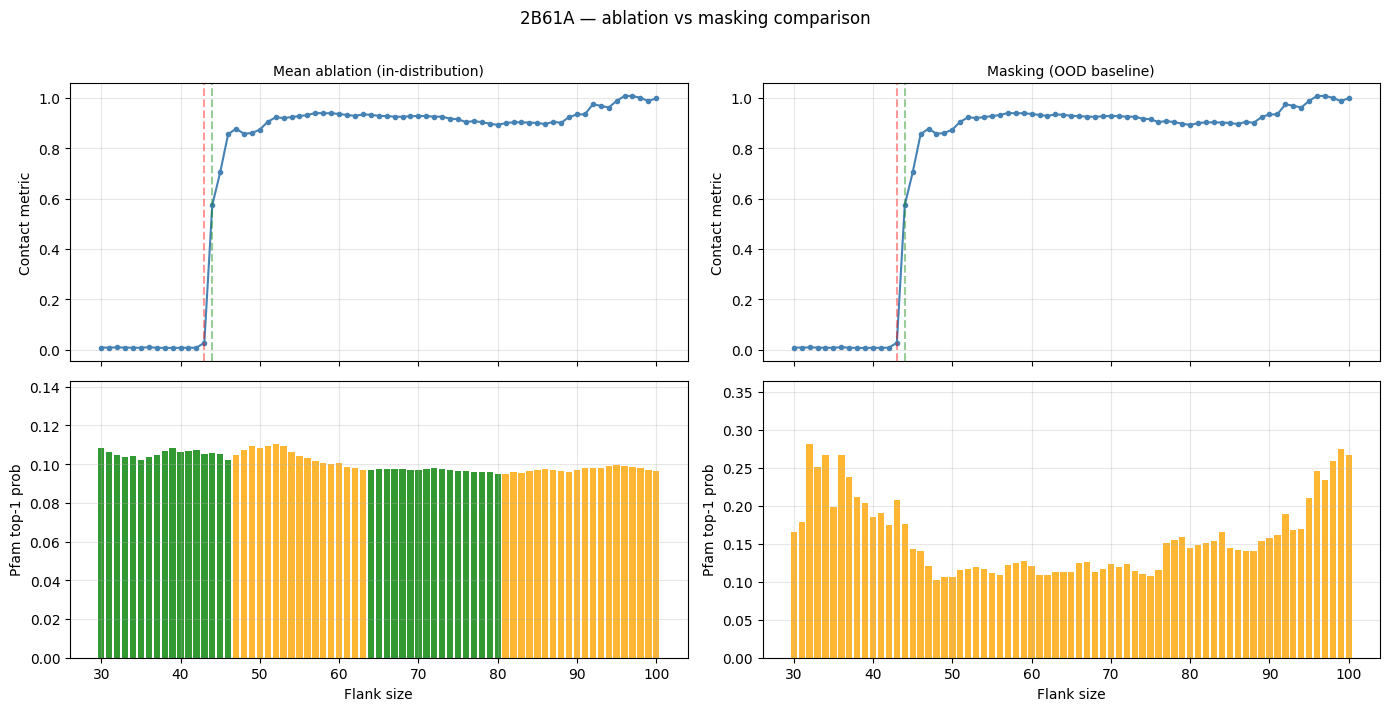

Saved to reports/outputs/2B61A_ablation_vs_mask.png


In [22]:
# =============================================================================
# Flank sweep — masked sequence through probe (no mean ablation)
# Directly comparable to the mean-ablation results above
# =============================================================================
def probe_with_masking(
    sequence_S : str,
    segment    : ContactSegment,
    flank_size : int,
) -> tuple[str, float, float]:
    """
    Run the MASKED sequence (as used for contact prediction) through ESM2,
    then mean-pool and probe. OOD but useful as a comparison baseline.
    """
    masked_seq = mask_with_flanks(sequence_S, segment, flank_size)
    enc = tokenizer(masked_seq, return_tensors="pt",
                    truncation=True, max_length=1022).to(device)
    with torch.no_grad():
        out    = esm_model.esm(**enc, output_hidden_states=True)
        h      = out.hidden_states[-1]               # [1, L, D]
        mask_  = enc["attention_mask"][:, 1:-1].unsqueeze(-1).float()
        h_inner = h[:, 1:-1, :]
        pooled  = (h_inner * mask_).sum(1) / mask_.sum(1)  # [1, D]

    probs   = probe.predict_proba(pooled.cpu().float().numpy())[0]
    top_idx = probs.argmax()
    entropy = -(probs * np.log(probs + 1e-10)).sum()
    return le.classes_[top_idx], probs[top_idx], entropy


print(f"\nFlank sweep — MASKED sequence (OOD baseline):")
print(f"{'─'*72}")
print(f"  {'flank':>6}  {'contact':>9}  {'pfam_fam':>12}  {'pfam_p':>8}  {'entropy':>8}  correct")
print(f"{'─'*72}")

mask_results = []
for flank in range(FLANK_START, FLANK_END + 1):
    masked_seq  = mask_with_flanks(sequence_S, segment, flank)
    contacts_AA = compute_contact_map(esm_model, tokenizer, masked_seq, device)
    contact_val = patching_metric(contacts_AA, orig_contacts_AA, segment)

    pfam_fam, pfam_p, entropy = probe_with_masking(sequence_S, segment, flank)
    correct = "✓" if pfam_fam == full_pred else "✗"

    mask_results.append({
        "flank": flank, "contact": contact_val,
        "pfam_fam": pfam_fam, "pfam_p": pfam_p,
        "entropy": entropy, "correct": pfam_fam == full_pred,
    })
    print(f"  {flank:>6}  {contact_val:>9.4f}  {pfam_fam:>12}  "
          f"{pfam_p:>8.4f}  {entropy:>8.3f}  {correct}")

print(f"{'─'*72}")
print(f"Correct when contact > 0.3: "
      f"{sum(1 for r in mask_results if r['contact'] > 0.3 and r['correct'])}"
      f"/{sum(1 for r in mask_results if r['contact'] > 0.3)}")

# ── Side-by-side comparison plot ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

flanks_arr  = np.array([r["flank"]   for r in ablation_results])
contact_arr = np.array([r["contact"] for r in ablation_results])

for col, (results, title) in enumerate([
    (ablation_results, "Mean ablation (in-distribution)"),
    (mask_results,     "Masking (OOD baseline)"),
]):
    ax_top, ax_bot = axes[0, col], axes[1, col]
    probs_arr   = np.array([r["pfam_p"]  for r in results])
    correct_arr = np.array([r["correct"] for r in results])
    colors      = ["green" if c else "orange" for c in correct_arr]

    ax_top.plot(flanks_arr, contact_arr, "o-", color="steelblue", lw=1.5, ms=3)
    ax_top.set_title(title, fontsize=10)
    ax_top.set_ylabel("Contact metric")
    ax_top.grid(True, alpha=0.3)
    ax_top.axvline(PROTEINS[protein]["corrupt_flank"], color="red",   ls="--", alpha=0.4)
    ax_top.axvline(PROTEINS[protein]["clean_flank"],   color="green", ls="--", alpha=0.4)

    ax_bot.bar(flanks_arr, probs_arr, color=colors, alpha=0.8)
    ax_bot.set_ylabel("Pfam top-1 prob")
    ax_bot.set_xlabel("Flank size")
    ax_bot.set_ylim(0, max(probs_arr) * 1.3)
    ax_bot.grid(True, alpha=0.3)

plt.suptitle(f"{protein} — ablation vs masking comparison", y=1.01)
plt.tight_layout()
outpath = f"{PLOT_DIR}/{protein}_ablation_vs_mask.png"
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {outpath}")

In [24]:
# Paste this whole cell and run. It fixes your error by:
# 1) calling polymer_entity_instance (2B61/A)
# 2) extracting entity_id from container_identifiers
# 3) calling polymer_entity (2B61/<entity_id>) to get the polymer sequence
# 4) printing SS spans + a visual marker line so you can sanity-check indices

import json
import requests
import pandas as pd
from difflib import SequenceMatcher

# ----------------------------
# 1) Load your sequence dict
# ----------------------------
DATA_PATH = "data/full_seq_dict.json"

with open(DATA_PATH, "r") as f:
    seq_dict = json.load(f)

protein = "2B61A"  # "PDBID"+"CHAIN"
sequence_S = seq_dict[protein]

pdb_id = protein[:4].upper()
chain_id = protein[4:].upper() or "A"

print(f"PDB: {pdb_id}, chain: {chain_id}")
print(f"Your sequence length: {len(sequence_S)}")

def _get(d, path, default=None):
    cur = d
    for k in path:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ---------------------------------------------------------
# 2) Fetch polymer_entity_instance and then polymer_entity
# ---------------------------------------------------------
inst_url = f"https://data.rcsb.org/rest/v1/core/polymer_entity_instance/{pdb_id}/{chain_id}"
inst = requests.get(inst_url, timeout=30)
inst.raise_for_status()
inst = inst.json()

entity_id = _get(inst, ["rcsb_polymer_entity_instance_container_identifiers", "entity_id"])
asym_id = _get(inst, ["rcsb_polymer_entity_instance_container_identifiers", "asym_id"])
auth_asym_id = _get(inst, ["rcsb_polymer_entity_instance_container_identifiers", "auth_asym_id"])

print(f"Instance IDs: entity_id={entity_id}, asym_id={asym_id}, auth_asym_id={auth_asym_id}")

if entity_id is None:
    raise ValueError(
        "Could not find entity_id under rcsb_polymer_entity_instance_container_identifiers. "
        f"Top-level keys: {sorted(list(inst.keys()))}"
    )

ent_url = f"https://data.rcsb.org/rest/v1/core/polymer_entity/{pdb_id}/{entity_id}"
ent = requests.get(ent_url, timeout=30)
ent.raise_for_status()
ent = ent.json()

# Polymer sequence usually lives here for polymer_entity
rcsb_seq = (
    _get(ent, ["entity_poly", "pdbx_seq_one_letter_code_can"])
    or _get(ent, ["entity_poly", "pdbx_seq_one_letter_code"])
)
if not rcsb_seq:
    raise ValueError(
        "Could not find polymer sequence in polymer_entity response.\n"
        f"Top-level keys: {sorted(list(ent.keys()))}\n"
        f"entity_poly keys: {sorted(list(ent.get('entity_poly', {}).keys())) if isinstance(ent.get('entity_poly'), dict) else ent.get('entity_poly')}"
    )

rcsb_seq = "".join(rcsb_seq.split())
print(f"RCSB polymer sequence length: {len(rcsb_seq)}")

# ---------------------------------------------------------
# 3) Secondary structure features (from the *instance* payload)
# ---------------------------------------------------------
features = inst.get("rcsb_polymer_instance_feature", []) or []
print(f"Number of positional features on instance: {len(features)}")

feature_types = sorted({f.get("type", "UNKNOWN") for f in features})
print("\nUnique feature types:")
print(", ".join(feature_types) if feature_types else "(none)")

def looks_like_ss(t: str) -> bool:
    tU = (t or "").upper()
    # This heuristic is intentionally broad because feature naming varies
    needles = ["HELIX", "STRAND", "SHEET", "TURN", "COIL", "SECONDARY", "SS"]
    return any(x in tU for x in needles)

ss_features = [f for f in features if looks_like_ss(f.get("type", ""))]

print(f"\nSS-like features kept: {len(ss_features)}")
print("Types among those:", ", ".join(sorted({f.get('type','UNKNOWN') for f in ss_features})) or "(none)")

rows = []
for f in ss_features:
    ftype = f.get("type", "UNKNOWN")
    for pos in f.get("feature_positions", []) or []:
        beg = pos.get("beg_seq_id")
        end = pos.get("end_seq_id")
        if isinstance(beg, int) and isinstance(end, int):
            rows.append({"type": ftype, "beg_seq_id": beg, "end_seq_id": end, "length": end - beg + 1})

ss_df = pd.DataFrame(rows).sort_values(["type", "beg_seq_id", "end_seq_id"]).reset_index(drop=True)
print("\nSS-like spans (RCSB polymer seq indices, 1-based):")
display(ss_df)

# ---------------------------------------------------------
# 4) Visualize a chosen SS feature type as a marker line
# ---------------------------------------------------------
def pick_primary_type(types):
    # Prefer helix-like, then strand-like, else first
    for key in ["HELIX", "STRAND", "SHEET"]:
        for t in types:
            if key in t.upper():
                return t
    return types[0] if types else None

primary_type = pick_primary_type(list(ss_df["type"].unique())) if len(ss_df) else None
print(f"\nPrimary SS feature type for visualization: {primary_type}" if primary_type else "\nNo SS spans found to visualize.")

def build_marks(L, spans):
    lab = ["." for _ in range(L)]
    for b, e in spans:
        for i in range(max(1, b), min(L, e) + 1):
            lab[i - 1] = "#"
    return "".join(lab)

def show_seq_with_marks(seq, marks, width=80):
    n = len(seq)
    for s in range(0, n, width):
        chunk = seq[s:s+width]
        mch = marks[s:s+width] if marks else "." * len(chunk)
        left = s + 1
        right = s + len(chunk)
        print(f"{left:>6}  {chunk}  {right:<6}")
        print(f"{'':>6}  {mch}")
        print()

if primary_type:
    spans = [(int(r.beg_seq_id), int(r.end_seq_id)) for r in ss_df[ss_df["type"] == primary_type].itertuples()]
    marks = build_marks(len(rcsb_seq), spans)

    print("\nRCSB polymer sequence with markers ('#' = covered by the chosen SS feature type):\n")
    show_seq_with_marks(rcsb_seq, marks, width=80)

# ---------------------------------------------------------
# 5) Map RCSB polymer seq indices onto YOUR sequence indices
# ---------------------------------------------------------
def map_indices_rcsb_to_user(rcsb_seq, user_seq):
    if rcsb_seq in user_seq:
        off = user_seq.find(rcsb_seq)  # 0-based
        return {"method": "rcsb_in_user_exact", "offset_user_minus_rcsb": off}
    if user_seq in rcsb_seq:
        off = rcsb_seq.find(user_seq)  # 0-based
        return {"method": "user_in_rcsb_exact", "offset_rcsb_minus_user": off}

    sm = SequenceMatcher(a=rcsb_seq, b=user_seq, autojunk=False)
    blocks = [b for b in sm.get_matching_blocks() if b.size > 0]
    blocks = sorted(blocks, key=lambda x: x.size, reverse=True)[:10]
    return {"method": "difflib_blocks", "blocks": [(b.a, b.b, b.size) for b in blocks]}

mapping = map_indices_rcsb_to_user(rcsb_seq, sequence_S)
print("\nMapping summary:", mapping["method"])
if mapping["method"] == "rcsb_in_user_exact":
    off = mapping["offset_user_minus_rcsb"]
    print(f"Exact containment: YOUR seq contains RCSB seq with 0-based offset={off}.")
    if len(ss_df):
        demo = ss_df.head(15).copy()
        demo["user_beg_seq_id"] = demo["beg_seq_id"] + off
        demo["user_end_seq_id"] = demo["end_seq_id"] + off
        print("\nFirst 15 SS spans mapped onto YOUR sequence indices (1-based):")
        display(demo)
elif mapping["method"] == "difflib_blocks":
    print("Top matching blocks (rcsb_start0, user_start0, length):")
    for a0, b0, sz in mapping["blocks"]:
        print(f"  ({a0}, {b0}, {sz})")

# ---------------------------------------------------------
# 6) Spot-check helper: pick a row in ss_df and print context
# ---------------------------------------------------------
def spot_check_span(row_i, flank=10):
    if row_i < 0 or row_i >= len(ss_df):
        raise IndexError("row_i out of range for ss_df")
    r = ss_df.iloc[row_i]
    b, e = int(r["beg_seq_id"]), int(r["end_seq_id"])  # 1-based
    b0, e0 = b - 1, e  # python slice end exclusive
    s0 = max(0, b0 - flank)
    e1 = min(len(rcsb_seq), e0 + flank)
    print(f"\nSpan row {row_i}: type={r['type']}, RCSB [beg,end]=[{b},{e}]")
    print(f"RCSB context ({s0+1}..{e1}):")
    print(rcsb_seq[s0:e1])
    print(" " * (b0 - s0) + "^" + "-" * max(0, e0 - b0 - 1) + "^")

print("\nTip: run spot_check_span(i) for any row i you see in ss_df.")
# Example:
# spot_check_span(0)

PDB: 2B61, chain: A
Your sequence length: 377
Instance IDs: entity_id=1, asym_id=A, auth_asym_id=A
RCSB polymer sequence length: 377
Number of positional features on instance: 35

Unique feature types:
ASA, AVERAGE_OCCUPANCY, CATH, CLASHES, ECOD, HELIX_P, NATOMS_EDS, OWAB, RSCC, RSR, RSRZ, SCOP, SCOP2_FAMILY, SCOP2_SUPERFAMILY, SHEET, UNASSIGNED_SEC_STRUCT, UNOBSERVED_RESIDUE_XYZ

SS-like features kept: 19
Types among those: HELIX_P, SHEET, UNASSIGNED_SEC_STRUCT

SS-like spans (RCSB polymer seq indices, 1-based):


,type,beg_seq_id,end_seq_id,length
0,HELIX_P,84,86,3
1,HELIX_P,127,131,5
2,HELIX_P,135,150,16
3,HELIX_P,162,175,14
4,HELIX_P,192,208,17
5,HELIX_P,212,216,5
6,HELIX_P,223,239,17
7,HELIX_P,240,248,9
8,HELIX_P,263,278,16
9,HELIX_P,281,295,15



Primary SS feature type for visualization: HELIX_P

RCSB polymer sequence with markers ('#' = covered by the chosen SS feature type):

     1  GSSHHHHHHSSGLVPRGSHMSVQNVVLFDTQPLTLMLGGKLSYINVAYQTYGTLNDEKNNAVLICHALTGDAEPYFDDGR  80    
        ................................................................................

    81  DGWWQNFMGAGLALDTDRYFFISSNVLGGCKGTTGPSSINPQTGKPYGSQFPNIVVQDIVKVQKALLEHLGISHLKAIIG  160   
        ...###........................................#####...################..........

   161  GSFGGMQANQWAIDYPDFMDNIVNLCSSIYFSAEAIGFNHVMRQAVINDPNFNGGDYYEGTPPDQGLSIARMLGMLTYRT  240   
        .##############................#################...#####......##################

   241  DLQLAKAFGRATKSDGSFWGDYFQVESYLSYQGKKFLERFDANSYLHLLRALDMYDPSLGYENVKEALSRIKARYTLVSV  320   
        ########..............################..###############.......#######...........

   321  TTDQLFKPIDLYKSKQLLEQSGVDLHFYEFPSDYGHDAFLVDYDQFEKRIRDGLAGN  377   
        ......###############............#

,type,beg_seq_id,end_seq_id,length,user_beg_seq_id,user_end_seq_id
0,HELIX_P,84,86,3,84,86
1,HELIX_P,127,131,5,127,131
2,HELIX_P,135,150,16,135,150
3,HELIX_P,162,175,14,162,175
4,HELIX_P,192,208,17,192,208
5,HELIX_P,212,216,5,212,216
6,HELIX_P,223,239,17,223,239
7,HELIX_P,240,248,9,240,248
8,HELIX_P,263,278,16,263,278
9,HELIX_P,281,295,15,281,295



Tip: run spot_check_span(i) for any row i you see in ss_df.
